# EDA (Exploratory Data Analysis)
## From SQL

In [2]:
import sys
import os
import pandas as pd

### Base de datos
conn = sqlite3.connect(db_path)             abres

df = pd.read_sql("SELECT...", conn)         lees

conn.close()                                cierras

In [6]:
import sqlite3

# Conectar a la base de datos
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(base_dir, "data", "electricity.db")
conn = sqlite3.connect(db_path)

# Cargar datos con SQL
df = pd.read_sql("SELECT * FROM omie_prices", conn)

#conn.close()

df.describe()

,month,day,hour,price_es,price_pt
count,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,6.531021,15.687157,12.500114,88.279625,87.104346
std,3.451845,8.785675,6.922781,39.983558,41.397270
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4.000000,8.000000,6.750000,65.880000,63.252500
50%,7.000000,16.000000,12.500000,92.500000,92.130000
75%,10.000000,23.000000,18.250000,116.145000,116.365000
max,12.000000,31.000000,25.000000,220.000000,220.000000


In [12]:
# Precio diario medio — con SQL
df_daily = pd.read_sql("""
    SELECT year, month, day, AVG(price_es) as avg_price, datetime
    FROM omie_prices
    GROUP BY year, month, day
    ORDER BY year, month, day
""", conn)

In [13]:
df_daily.head(5)

,year,month,day,avg_price,datetime
0,2023,1.0,1.0,6.697083,2023-01-01 00:00:00
1,2023,1.0,2.0,110.082500,2023-01-02 00:00:00
2,2023,1.0,3.0,136.854167,2023-01-03 00:00:00
3,2023,1.0,4.0,115.257083,2023-01-04 00:00:00
4,2023,1.0,5.0,108.514167,2023-01-05 00:00:00


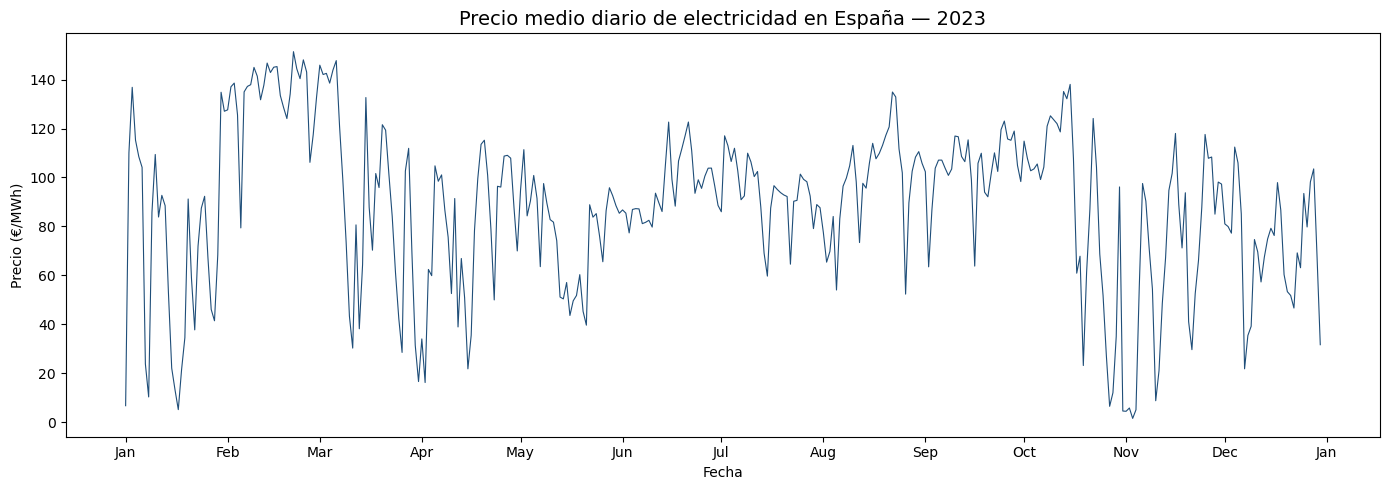

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_daily["datetime"], df_daily["avg_price"], linewidth=0.8, color="#1F4E79")
ax.set_title("Precio medio diario de electricidad en España — 2023", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig("../outputs/precio_diario_2023.png", dpi=150)
plt.show()

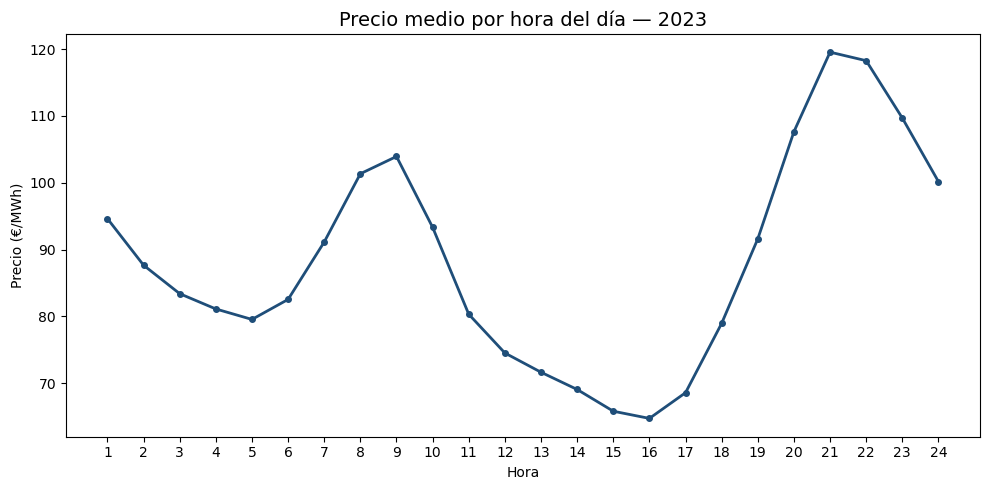

In [28]:
df_hourly = pd.read_sql("""
    SELECT hour, AVG(price_es) as avg_price
    FROM omie_prices
    GROUP BY hour
    ORDER BY hour
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_hourly["hour"][0:24], df_hourly["avg_price"][0:24], 
        linewidth=2, color="#1F4E79", marker="o", markersize=4)
ax.set_title("Precio medio por hora del día — 2023", fontsize=14)
ax.set_xlabel("Hora")
ax.set_ylabel("Precio (€/MWh)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.savefig("../outputs/precio_por_hora_2023.png", dpi=150)
plt.show()

'Curva de Pato'. Bajada pronunciada en horas de pico solor por alta actividad fotovoltaica. La demanda realmente es grande pero la energia es barata.

In [29]:
df_weekday = pd.read_sql("""
    SELECT 
        CAST(strftime('%w', datetime) AS INTEGER) as weekday,
        AVG(price_es) as avg_price
    FROM omie_prices
    WHERE hour BETWEEN 1 AND 24
    GROUP BY weekday
    ORDER BY weekday
""", conn)

In [31]:
pd.read_sql("""
    SELECT datetime, CAST(strftime('%w', datetime) AS INTEGER) as weekday
    FROM omie_prices
    WHERE datetime LIKE '2023-01-01%'
    LIMIT 1
""", conn)

,datetime,weekday
0,2023-01-01 00:00:00,0


Ok, Number 0 is Sunday

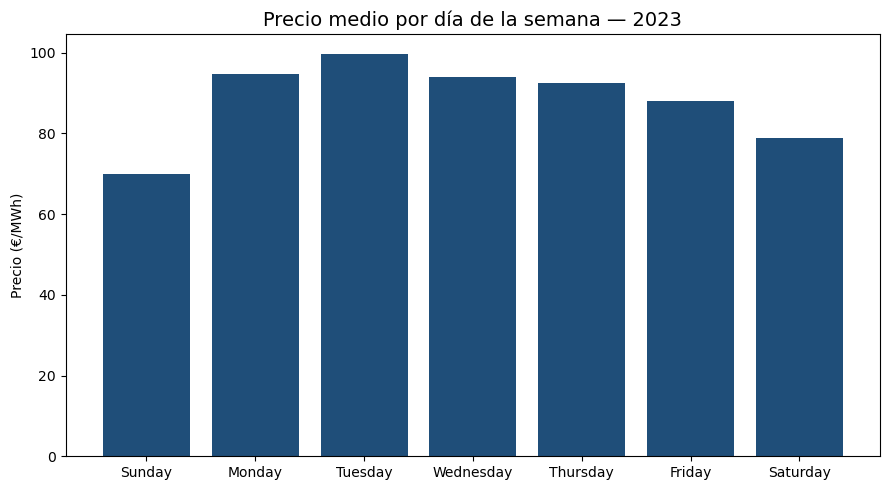

In [32]:
weekday_names = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df_weekday["weekday_name"] = df_weekday["weekday"].map(lambda x: weekday_names[x])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_weekday["weekday_name"], df_weekday["avg_price"], color="#1F4E79")
ax.set_title("Precio medio por día de la semana — 2023", fontsize=14)
ax.set_ylabel("Precio (€/MWh)")
plt.tight_layout()
plt.savefig("../outputs/precio_por_dia_semana_2023.png", dpi=150)
plt.show()

On Sunday there is less industry, less demand, prices are the lowest. On Saturday it is also below labor days. Maximum is on Tuesdays, probably on the whole year there are not many holidays on Tuesdays

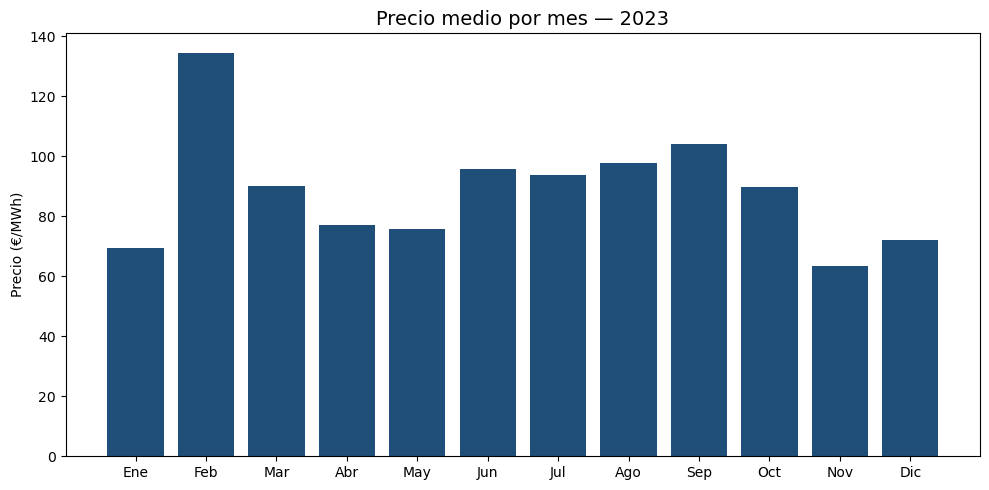

In [34]:
df_monthly = pd.read_sql("""
    SELECT month, AVG(price_es) as avg_price
    FROM omie_prices
    WHERE hour BETWEEN 1 AND 24
    GROUP BY month
    ORDER BY month
""", conn)

month_names = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", 
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
df_monthly["month_name"] = df_monthly["month"].astype('int').map(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_monthly["month_name"], df_monthly["avg_price"], color="#1F4E79")
ax.set_title("Precio medio por mes — 2023", fontsize=14)
ax.set_ylabel("Precio (€/MWh)")
plt.tight_layout()
plt.savefig("../outputs/precio_por_mes_2023.png", dpi=150)
plt.show()

Incredibly high in February. 

### Outliers detection

We already have:
1) Price per day in the year
2) Mean Price per hour in the day (duck shape)
3) Mean Price of the dayweeks (distintion between labor and vacation)
4) Mean Price of the months along the year (seasonal peaks like February)

Now, let's see if there are outliers like negative prices (when renewables are in excedent) or too expensive prices (eg more than 200)

In [35]:
pd.read_sql("""
    SELECT year, month, day, hour, price_es
    FROM omie_prices
    WHERE price_es <= 0
    AND hour BETWEEN 1 AND 24
    ORDER BY price_es
""", conn)

,year,month,day,hour,price_es
0,2023,1.0,1.0,1.0,0.0
1,2023,1.0,1.0,2.0,0.0
2,2023,1.0,1.0,3.0,0.0
3,2023,1.0,1.0,4.0,0.0
4,2023,1.0,1.0,5.0,0.0
...,...,...,...,...,...
65,2023,11.0,5.0,15.0,0.0
66,2023,11.0,5.0,16.0,0.0
67,2023,11.0,5.0,17.0,0.0
68,2023,12.0,31.0,5.0,0.0


In [36]:
pd.read_sql("""
    SELECT year, month, day, hour, price_es
    FROM omie_prices
    WHERE price_es > 200
    AND hour BETWEEN 1 AND 24
    ORDER BY price_es DESC
""", conn)

,year,month,day,hour,price_es
0,2023,1.0,24.0,20.0,220.00
1,2023,1.0,30.0,20.0,220.00
2,2023,1.0,24.0,21.0,218.08
3,2023,10.0,23.0,21.0,215.02
4,2023,1.0,25.0,20.0,210.34
5,2023,1.0,20.0,20.0,207.80


Perfectly normal data.
1) 70 days of zero price due to more generation of fotovoltaic than the demand. There are also a lot of zeros on January, November, December. The explanation is in hidraulic and eolic.
2) 6 really expensive days due to lack of production.

In [37]:
pd.read_sql("""
    SELECT month, COUNT(*) as num_ceros
    FROM omie_prices
    WHERE price_es = 0
    AND hour BETWEEN 1 AND 24
    GROUP BY month
    ORDER BY month
""", conn)

,month,num_ceros
0,1.0,13
1,3.0,7
2,4.0,12
3,5.0,3
4,7.0,1
5,8.0,6
6,10.0,7
7,11.0,19
8,12.0,2


La diferencia es que la solar es predecible y gradual — sube y baja cada día de forma suave, el mercado la anticipa y ajusta. La hidráulica en cambio puede inyectar grandes cantidades de golpe cuando los embalses están llenos y hay que desembalsar, saturando el mercado en horas que no son pico solar.
Además España tiene una capacidad hidráulica enorme — es uno de los países europeos con más embalses — así que cuando llueve mucho el efecto es muy grande.

In [38]:
conn.close()